### More Pytorchyfication of code

In [32]:
import torch 
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [33]:
words=open('names.txt','r').read().splitlines()
print(words[:8])
len(words)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


32033

In [34]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [35]:
def build_dataset(words):
    block_size=8
    X,Y=[],[]
    for w in words:
        context=[0]*block_size
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+[ix]

    X=torch.tensor(X)
    Y=torch.tensor(Y)
    return X,Y


# Creating Training , Validation and Test sets
random.seed(42)
random.shuffle(words)

n1=int(len(words)*0.8)
n2=int(len(words)*0.9)
Xtr,Ytr=build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xte,Yte=build_dataset(words[n2:])

print("Shape of X:",Xtr.shape) # Means there are 3 characters in the context in 32 training examples.
print("Data type of X:",Xtr.dtype)
print("Shape of Y:",Ytr.shape) # Means there is only 1 output character in 32 training examples.
print("Data type of Y:",Ytr.dtype)

Shape of X: torch.Size([182625, 8])
Data type of X: torch.int64
Shape of Y: torch.Size([182625])
Data type of Y: torch.int64


In [ ]:
# Making A Deeper Model Network: Model from lecture 3:

class Linear:
    def __init__(self,fan_in,fan_out,bias=True):
        self.weights=torch.randn((fan_in,fan_out),generator=g)/fan_in**0.5
        self.bias=torch.zeros(fan_out) if bias else None

    def __call__(self,x):
        self.out=x @ self.weights
        if self.bias is not None:
            self.out+=self.bias
        return self.out

    def parameters(self):
        return [self.weights]+ ([] if self.bias is None else [self.bias])

#----------------------------------------------------------------------------------------------------------#

class BatchNorm1d:
    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps=eps
        self.momentum=momentum
        self.training=True
        #Parameters to learn:
        self.gamma=torch.ones(dim) 
        self.beta=torch.zeros(dim) 
        #Buffers(not parameters, but part of the state of the module that will be used in inference mode):
        self.running_mean=torch.zeros(dim)
        self.running_var=torch.ones(dim)

    def __call__(self,x):
        if self.training:
            xmean=x.mean(0,keepdim=True)
            xvar=x.var(0,keepdim=True)
        else:
            xmean=self.running_mean
            xvar=self.running_var
        xhat=(x-xmean)/(torch.sqrt(xvar+self.eps))
        self.out=self.gamma*xhat+self.beta
        #update the buffers:
        if self.training:
            with torch.no_grad():
                self.running_mean=(1-self.momentum)*self.running_mean+self.momentum*xmean
                self.running_var=(1-self.momentum)*self.running_var+self.momentum*xvar
        
        return self.out

    def parameters(self):
        return [self.gamma,self.beta]

#----------------------------------------------------------------------------------------------------------#
    
class tanh:
    def __call__(self,x):
        self.out=torch.tanh(x)
        return self.out

    def parameters(self):
        return []

#----------------------------------------------------------------------------------------------------------#

class embeddings:
    def __init__(self,num_embedings,embeddings_dim):
        self.weight=torch.randn((num_embedings,embeddings_dim))

    def __call__(self, IX):
        self.out=self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]

#----------------------------------------------------------------------------------------------------------#

class flatten:
    def __call__(self,x):
        self.out=x.view(x.shape[0],-1)
        return self.out

    def parameters(self):
        return []

#----------------------------------------------------------------------------------------------------------#

class sequential:
    def __init__(self,layers):
        self.layers=layers

    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        self.out=x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

n_embed=10
n_hidden=200
block_size=8
vocab_size=27
g=torch.Generator().manual_seed(2147483647)

# Model  parameters:

model=sequential([
    embeddings(vocab_size,n_embed),
    flatten(),
    Linear(n_embed*block_size,n_hidden),
    BatchNorm1d(n_hidden),
    tanh(),
    Linear(n_hidden,vocab_size)
])

# 1 / sqrt(fan_in) keeps the linear layer stable.
# It prevents the dot product from exploding just because there are many inputs.
# But after that, you apply tanh, which is also a squashing function.
# Tanh compresses values toward −1 and 1, which slightly reduces variance.
# Now when you stack many layers:

# Linear (stable) → tanh (shrinks a bit)
# Linear (stable) → tanh (shrinks a bit)
# …
# That “shrinks a bit” compounds across layers.
# So the signal slowly gets smaller and gradients weaken.
# The 5/3 factor is just a correction for tanh’s shrinking effect.

with torch.no_grad():
    #Applying Gain Scaling to the other layers:
    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weights*=5/3

parameters=model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

22297


### Optimization 5: Increasing context Length:

In [59]:
#Training Block:

epochs=200000
batch_size=32
losses=[]

for epoch in range(epochs):
    #Minibatch construct:
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb, Yb=Xtr[ix],Ytr[ix]

    # Do the Forward pass:
    logits=model(Xb)

    #Calulate the loss:
    loss=F.cross_entropy(logits,Yb)

    #Backward pass:
    for layer in layers:
        layer.out.retain_grad() # retain the gradients for each layer's output for backpropagation

    # Optimizer Zero_grad:
    for p in parameters:
        p.grad=None

    # Loss Backward:
    loss.backward()

    #Updating the parameters:
    #optimizer step-step:
    lr=0.1 if epoch<100000 else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    #Track the loss:
    if epoch%10000==0:
        print(f'{epoch:7d}/{epochs} : {loss.item():.4f}')
        losses.append(loss.log10().item())


      0/200000 : 3.6688
  10000/200000 : 2.5818
  20000/200000 : 2.4740
  30000/200000 : 1.8200
  40000/200000 : 2.2358
  50000/200000 : 2.1971
  60000/200000 : 2.6378
  70000/200000 : 2.0814
  80000/200000 : 1.6886
  90000/200000 : 1.9778
 100000/200000 : 2.1214
 110000/200000 : 1.9684
 120000/200000 : 1.8217
 130000/200000 : 2.1590
 140000/200000 : 2.0387
 150000/200000 : 2.2551
 160000/200000 : 1.6444
 170000/200000 : 2.2837
 180000/200000 : 1.8534
 190000/200000 : 2.0789


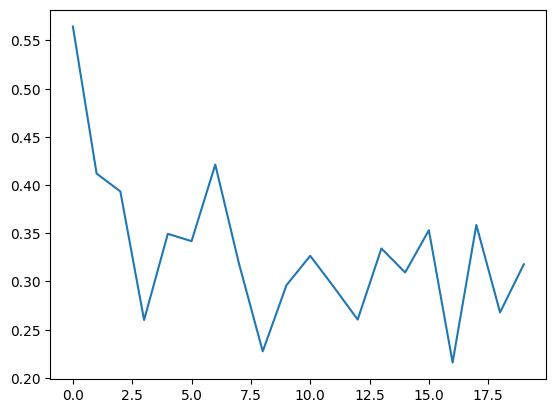

In [60]:
plt.plot(losses)

In [61]:
with torch.no_grad():
    logits=model(Xtr)
    loss = F.cross_entropy(logits, Ytr)
    print(loss.item())

1.9278324842453003


In [62]:
with torch.no_grad():
    logits=model(Xdev)
    loss = F.cross_entropy(logits, Ydev)
    print(loss.item())


2.0238146781921387


In [63]:
# switch batchnorm to eval
for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

for _ in range(10):
    out = []
    context = [0] * block_size

    while True:
        x = torch.tensor([context], dtype=torch.long)
        logits = model(x)
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(probs, num_samples=1).item()

        out.append(itos[ix])
        context = context[1:] + [ix]

        if ix == 0:
            break

    print(''.join(out))

mano.
aorianna.
paisov.
acrab.
isabella.
youlia.
roshai.
cheris.
kyriana.
wesley.


In [ ]:
# ORIGINAL:
# TRAINING LOSS:2.2935421466827393
# DEVLOPEMENT LOSS:2.2988171577453613

# OPTIMIZATION 1 (MORE HIDDEN NEURON):
# TRAINING LOSS:2.3274359703063965
# DEVLOPEMENT LOSS:2.3389434814453125

# OPTIMIZATION 2 (BIGGER LOOKUP TABLE) AND OPTIMIZATION 3 (BETTER INITIALIZATION-KAIMING):
# TRAINING LOSS:2.099210023880005
# DEVLOPEMENT LOSS:2.1369383335113525

# OPTIMIZATION 4 (BATCH NORMALIZATION):
# TRAINING LOSS:2.0580813884735107
# DEVLOPMENT LOSS:2.103177547454834

# OPTIMIZATION 5 (INCRESING CONTEXT LENGTH(BLOCK SIZE)(3->8)):
# TRAINING LOSS: 1.9278324842453003
# DEVLOPMENT LOSS: 2.0238146781921387

# WAVENET:
# TRAINING LOSS:1.9505549669265747
# DEVLOPMENT LOSS:2.0282342433929443

# WAVENET (BatchNorm_Bug fixed):
# TRAINING LOSS:1.9249498844146729
# DEVLOPMENT LOSS:2.0216619968414307


# WaveNet Implementation:

In this WaveNet-inspired architecture, instead of flattening the entire context at once into a single large vector, the model compresses the temporal dimension hierarchically. Starting with an input of shape (B, 8, 10) after embedding, it groups consecutive tokens in stages: first 8 → 4 (each group represents 2 tokens), then 4 → 2 (each group represents 4 tokens), and finally 2 → 1 (representing all 8 tokens). At each stage, the feature dimension increases while the time dimension decreases, and a Linear → BatchNorm → Tanh block learns increasingly higher-level interactions. This results in exponential growth of the receptive field (2, 4, 8), allowing the model to build structured, hierarchical representations of the context instead of treating all tokens uniformly as in a flat MLP.

(4,8,10)->(4,80)
becomes structured as
(4, 4, 20) → (4, 2, 40) → (4, 1, 80)


In your corrected Wave-style BatchNorm, the normalization statistics are computed across both the batch (B) and time (T) dimensions for each channel. Earlier, statistics were effectively computed separately per time step, which made normalization position-dependent and less stable. Now, by averaging over B × T values, each feature channel shares a single mean and variance across all positions in the batch. This produces more consistent, channel-wise normalization and better aligns with how convolutional models handle feature maps. The result is improved stability and reduced position bias, especially in hierarchical temporal compression architectures like your Wave-style model.

In [85]:
# Making A Deeper Model Network: Model from lecture 3: Changes in the flatten layer as instaed of (4,80) of flatten layer we want(4,4,20)

class Linear:
    def __init__(self,fan_in,fan_out,bias=True):
        self.weights=torch.randn((fan_in,fan_out),generator=g)/fan_in**0.5
        self.bias=torch.zeros(fan_out) if bias else None

    def __call__(self,x):
        self.out=x @ self.weights
        if self.bias is not None:
            self.out+=self.bias
        return self.out

    def parameters(self):
        return [self.weights]+ ([] if self.bias is None else [self.bias])

#----------------------------------------------------------------------------------------------------------#

class BatchNorm1d:
    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps=eps
        self.momentum=momentum
        self.training=True
        #Parameters to learn:
        self.gamma=torch.ones(dim) 
        self.beta=torch.zeros(dim) 
        #Buffers(not parameters, but part of the state of the module that will be used in inference mode):
        self.running_mean=torch.zeros(dim)
        self.running_var=torch.ones(dim)

    def __call__(self,x):
        if self.training: #### WAVENET SPECIFIC CHANGES:::
            if x.ndim==3:
                dim=(0,1)
                keepdim=True
            else:
                dim=0
                keepdim=True
            xmean=x.mean(dim,keepdim=True)
            xvar=x.var(dim,keepdim=True)
        else:
            xmean=self.running_mean
            xvar=self.running_var
        xhat=(x-xmean)/(torch.sqrt(xvar+self.eps))
        self.out=self.gamma*xhat+self.beta
        #update the buffers:
        if self.training:
            with torch.no_grad():
                self.running_mean=(1-self.momentum)*self.running_mean+self.momentum*xmean
                self.running_var=(1-self.momentum)*self.running_var+self.momentum*xvar
        
        return self.out

    def parameters(self):
        return [self.gamma,self.beta]

#----------------------------------------------------------------------------------------------------------#
    
class tanh:
    def __call__(self,x):
        self.out=torch.tanh(x)
        return self.out

    def parameters(self):
        return []

#----------------------------------------------------------------------------------------------------------#

class embeddings:
    def __init__(self,num_embedings,embeddings_dim):
        self.weight=torch.randn((num_embedings,embeddings_dim))

    def __call__(self, IX):
        self.out=self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]

#----------------------------------------------------------------------------------------------------------#

class flattenConsecutive:
    def __init__(self,n):
        self.n=n

    def __call__(self,x):
        B,T,C=x.shape
        x=x.view(B,T//self.n,C*self.n)
        if x.shape[1]==1:
            x=x.squeeze(1)
        self.out=x
        return self.out
        
    def parameters(self):
        return []

#----------------------------------------------------------------------------------------------------------#

class sequential:
    def __init__(self,layers):
        self.layers=layers

    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        self.out=x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

n_embed=10
n_hidden=68
block_size=8
vocab_size=27
g=torch.Generator().manual_seed(2147483647)

# Model  parameters:

WaveModel=sequential([
    embeddings(vocab_size,n_embed),
    flattenConsecutive(2),Linear(n_embed*2,n_hidden),BatchNorm1d(n_hidden),tanh(),
    flattenConsecutive(2),Linear(n_hidden*2,n_hidden),BatchNorm1d(n_hidden),tanh(),
    flattenConsecutive(2),Linear(n_hidden*2,n_hidden),BatchNorm1d(n_hidden),tanh(),
    Linear(n_hidden,vocab_size)
])

# 1 / sqrt(fan_in) keeps the linear layer stable.
# It prevents the dot product from exploding just because there are many inputs.
# But after that, you apply tanh, which is also a squashing function.
# Tanh compresses values toward −1 and 1, which slightly reduces variance.
# Now when you stack many layers:

# Linear (stable) → tanh (shrinks a bit)
# Linear (stable) → tanh (shrinks a bit)
# …
# That “shrinks a bit” compounds across layers.
# So the signal slowly gets smaller and gradients weaken.
# The 5/3 factor is just a correction for tanh’s shrinking effect.

with torch.no_grad():
    #Applying Gain Scaling to the other layers:
    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weights*=5/3

parameters=WaveModel.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

22601


In [86]:
#Training Block:

epochs=200000
batch_size=32
losses=[]

for epoch in range(epochs):
    #Minibatch construct:
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb, Yb=Xtr[ix],Ytr[ix]

    # Do the Forward pass:
    logits=WaveModel(Xb)

    #Calulate the loss:
    loss=F.cross_entropy(logits,Yb)

    #Backward pass:
    for layer in layers:
        layer.out.retain_grad() # retain the gradients for each layer's output for backpropagation

    # Optimizer Zero_grad:
    for p in parameters:
        p.grad=None

    # Loss Backward:
    loss.backward()

    #Updating the parameters:
    #optimizer step-step:
    lr=0.1 if epoch<100000 else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    #Track the loss:
    if epoch%10000==0:
        print(f'{epoch:7d}/{epochs} : {loss.item():.4f}')
        losses.append(loss.log10().item())


      0/200000 : 3.6055
  10000/200000 : 2.1510
  20000/200000 : 1.8970
  30000/200000 : 2.1441
  40000/200000 : 2.0408
  50000/200000 : 1.6055
  60000/200000 : 2.1240
  70000/200000 : 1.8189
  80000/200000 : 2.3711
  90000/200000 : 2.0133
 100000/200000 : 1.6109
 110000/200000 : 1.9519
 120000/200000 : 2.1100
 130000/200000 : 2.0474
 140000/200000 : 2.2390
 150000/200000 : 2.2952
 160000/200000 : 1.8334
 170000/200000 : 1.8522
 180000/200000 : 2.1024
 190000/200000 : 2.0837


In [87]:
with torch.no_grad():
    logits=WaveModel(Xtr)
    loss = F.cross_entropy(logits, Ytr)
    print(loss.item())

1.9249498844146729


In [88]:
with torch.no_grad():
    logits=WaveModel(Xdev)
    loss = F.cross_entropy(logits, Ydev)
    print(loss.item())

2.0216619968414307
